In [1]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"humerag37python","key":"6f68c794d0ae0f63ca9cb49122ce8044"}'}

In [2]:
!mv "kaggle (1).json" kaggle.json

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
 98% 770M/788M [00:03<00:00, 169MB/s]
100% 788M/788M [00:03<00:00, 223MB/s]


In [5]:
!unzip microsoft-catsvsdogs-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/550.jpg   
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [7]:
IMG_SIZE = (96, 96)
BATCH_SIZE = 32
SEED = 42

In [15]:
train_ds = keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 24991 files belonging to 2 classes.
Using 17494 files for training.
Found 24991 files belonging to 2 classes.
Using 7497 files for validation.


In [16]:
val_size = int(0.5 * len(temp_ds))

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

Classes: ['Cat', 'Dog']


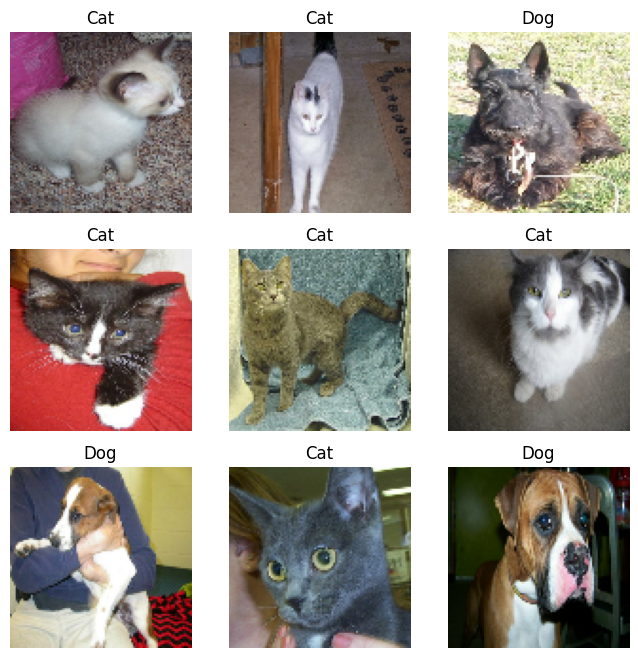

In [10]:
class_names = train_ds.class_names
print("Classes:", class_names)

plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [17]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [18]:
model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
import os
import tensorflow as tf

dataset_path = "PetImages"

num_deleted = 0

for folder in ["Cat", "Dog"]:
    folder_path = os.path.join(dataset_path, folder)

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        try:
            img = tf.io.read_file(file_path)
            tf.image.decode_image(img)
        except:
            os.remove(file_path)
            num_deleted += 1

print("Deleted corrupted images:", num_deleted)

Deleted corrupted images: 11


In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.5835 - loss: 0.6604 - val_accuracy: 0.7297 - val_loss: 0.5341
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.7350 - loss: 0.5311 - val_accuracy: 0.7917 - val_loss: 0.4503
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.7924 - loss: 0.4499 - val_accuracy: 0.8170 - val_loss: 0.3987
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.8223 - loss: 0.3936 - val_accuracy: 0.8427 - val_loss: 0.3623
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8517 - loss: 0.3372 - val_accuracy: 0.8592 - val_loss: 0.3341


In [21]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8562 - loss: 0.3308
Test Accuracy: 0.8566480278968811


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [23]:
!ls

 kaggle.json			   'MSR-LA - 3467.docx'  'readme[1].txt'
 microsoft-catsvsdogs-dataset.zip   PetImages		  sample_data


In [24]:
!unzip -qo microsoft-catsvsdogs-dataset.zip

In [25]:
!ls

 kaggle.json			   'MSR-LA - 3467.docx'  'readme[1].txt'
 microsoft-catsvsdogs-dataset.zip   PetImages		  sample_data


In [26]:
!ls PetImages

Cat  Dog


In [27]:
import os
from PIL import Image

dataset_dir = "PetImages"

for folder in ["Cat", "Dog"]:
    folder_path = os.path.join(dataset_dir, folder)
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        try:
            img = Image.open(file_path)
            img.verify()
        except:
            os.remove(file_path)

print("Corrupted images removed ✅")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted images removed ✅


In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    "PetImages",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "PetImages",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [29]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [31]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 332s 501ms/step - accuracy: 0.9609 - loss: 0.0955 - val_accuracy: 0.9812 - val_loss: 0.0488
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 292s 467ms/step - accuracy: 0.9827 - loss: 0.0462 - val_accuracy: 0.9840 - val_loss: 0.0457
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 469ms/step - accuracy: 0.9859 - loss: 0.0391 - val_accuracy: 0.9818 - val_loss: 0.0518
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 299s 478ms/step - accuracy: 0.9840 - loss: 0.0376 - val_accuracy: 0.9850 - val_loss: 0.0426
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 292s 467ms/step - accuracy: 0.9861 - loss: 0.0369 - val_accuracy: 0.9846 - val_loss: 0.0387


In [33]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 319s 484ms/step - accuracy: 0.9454 - loss: 0.1381 - val_accuracy: 0.9800 - val_loss: 0.0571
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 469ms/step - accuracy: 0.9762 - loss: 0.0610 - val_accuracy: 0.9842 - val_loss: 0.0419
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 294s 470ms/step - accuracy: 0.9799 - loss: 0.0535 - val_accuracy: 0.9846 - val_loss: 0.0396
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 294s 470ms/step - accuracy: 0.9825 - loss: 0.0466 - val_accuracy: 0.9838 - val_loss: 0.0434
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 291s 466ms/step - accuracy: 0.9840 - loss: 0.0408 - val_accuracy: 0.9856 - val_loss: 0.0373
